<a href="https://colab.research.google.com/github/TanveshRongala/assignment-01-BITSoM_BA_2511449/blob/main/part4-vector-db/embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install sentence-transformers seaborn matplotlib

from sentence_transformers import SentenceTransformer
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
sentences = [
    # Cricket (4)
    "The batsman scored a century in the final match.",
    "The bowler delivered a fast yorker to take the wicket.",
    "The team celebrated their victory after a thrilling chase.",
    "Fielders saved crucial runs near the boundary line.",

    # Cooking (3)
    "The chef prepared a delicious pasta with fresh ingredients.",
    "Baking a cake requires precise measurements and timing.",
    "The recipe includes spices and herbs for rich flavor.",

    # Cybersecurity (3)
    "Strong passwords are essential to protect user accounts.",
    "Encryption ensures that sensitive data remains secure.",
    "Firewalls help prevent unauthorized access to networks."
]

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (10, 384)


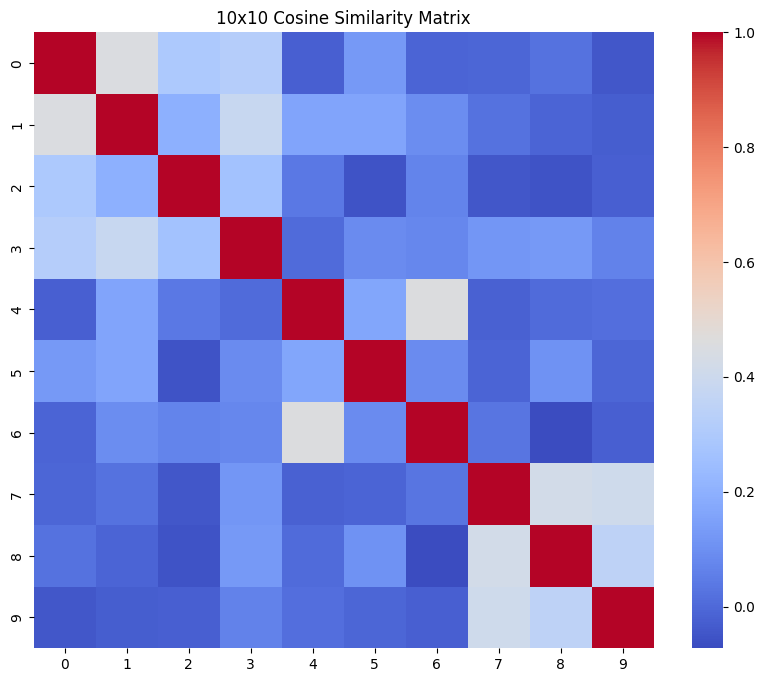

In [ ]:
similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=False, cmap="coolwarm")
plt.title("10x10 Cosine Similarity Matrix")
plt.show()

In [ ]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 indices
top_indices = similarities.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 most similar sentences:\n")

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}\n")

Query: The bowler took three wickets in one over

Top 2 most similar sentences:

Sentence: The bowler delivered a fast yorker to take the wicket.
Similarity Score: 0.6730

Sentence: The batsman scored a century in the final match.
Similarity Score: 0.5679

